In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Audio
import librosa
import librosa.display

# MiniLearn 
import minilearn

In [3]:
import sys
import os
sys.path.append('..')  

In [4]:
EMOTION_MAP = {
    1: 'neutral',  2: 'calm',     3: 'happy',    4: 'sad',
    5: 'angry',    6: 'fearful',  7: 'disgust',  8: 'surprised'
}

def parse_ravdess(data_dir):
    records = []
    for root, _, files in os.walk(data_dir):
        for fname in files:
            if not fname.endswith('.wav'):
                continue
            parts = fname.replace('.wav', '').split('-')
            if len(parts) != 7:
                continue
            actor = int(parts[6])
            records.append({
                'filepath'  : os.path.join(root, fname),
                'modality'  : int(parts[0]),
                'channel'   : int(parts[1]),   # 1=speech, 2=song
                'emotion'   : int(parts[2]),
                'intensity' : int(parts[3]),
                'statement' : int(parts[4]),
                'repetition': int(parts[5]),
                'actor'     : actor,
                'gender'    : 'female' if actor % 2 == 0 else 'male',
                'label'     : EMOTION_MAP[int(parts[2])]
            })
    return pd.DataFrame(records)

df = parse_ravdess('../data/')
print(f"Total files loaded: {len(df)}")
df.head()

Total files loaded: 2452


,filepath,modality,channel,emotion,intensity,statement,repetition,actor,gender,label
0,../data/Actor_01\03-01-01-01-01-01-01.wav,3,1,1,1,1,1,1,male,neutral
1,../data/Actor_01\03-01-01-01-01-02-01.wav,3,1,1,1,1,2,1,male,neutral
2,../data/Actor_01\03-01-01-01-02-01-01.wav,3,1,1,1,2,1,1,male,neutral
3,../data/Actor_01\03-01-01-01-02-02-01.wav,3,1,1,1,2,2,1,male,neutral
4,../data/Actor_01\03-01-02-01-01-01-01.wav,3,1,2,1,1,1,1,male,calm


In [5]:
print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nEmotion counts:")
print(df['label'].value_counts())
print("\nChannel split (1=speech, 2=song):")
print(df['channel'].value_counts())

Shape: (2452, 10)

Column types:
filepath        str
modality      int64
channel       int64
emotion       int64
intensity     int64
statement     int64
repetition    int64
actor         int64
gender          str
label           str
dtype: object

Missing values:
filepath      0
modality      0
channel       0
emotion       0
intensity     0
statement     0
repetition    0
actor         0
gender        0
label         0
dtype: int64

Emotion counts:
label
calm         376
happy        376
sad          376
angry        376
fearful      376
disgust      192
surprised    192
neutral      188
Name: count, dtype: int64

Channel split (1=speech, 2=song):
channel
1    1440
2    1012
Name: count, dtype: int64


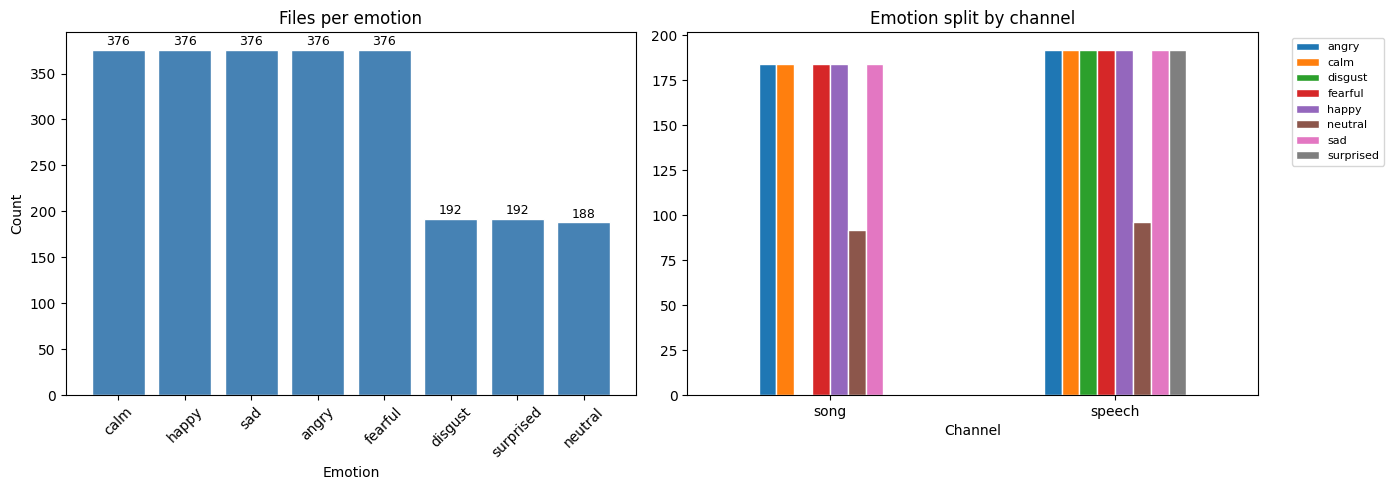

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# overall emotion distribution
counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Files per emotion')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

# speech vs song breakdown
channel_map  = {1: 'speech', 2: 'song'}
df['channel_name'] = df['channel'].map(channel_map)
pivot = df.groupby(['channel_name', 'label']).size().unstack(fill_value=0)
pivot.plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title('Emotion split by channel')
axes[1].set_xlabel('Channel')
axes[1].set_xticklabels(['song', 'speech'], rotation=0)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
#Looking at the waveforms, angry and surprised files show higher amplitude (louder). 
#Calm and neutral are more uniform. 
#The mel spectrograms show clear differences in frequency content between emotions.

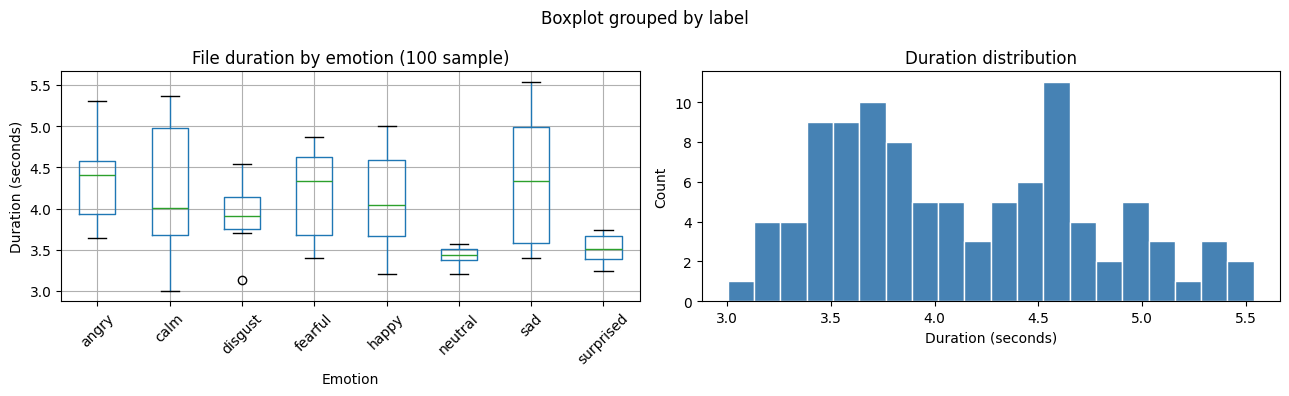

Sample rates found: [48000]
Duration stats:
count    100.000000
mean       4.126788
std        0.622336
min        3.003000
25%        3.628615
50%        4.004000
75%        4.604589
max        5.538854
Name: duration, dtype: float64


In [10]:
durations = []
for _, row in df.sample(100, random_state=42).iterrows():
    y_audio, sr = librosa.load(row['filepath'], sr=None)
    durations.append({
        'label'    : row['label'],
        'duration' : librosa.get_duration(y=y_audio, sr=sr),
        'sr'       : sr
    })

dur_df = pd.DataFrame(durations)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

dur_df.boxplot(column='duration', by='label', ax=axes[0])
axes[0].set_title('File duration by emotion (100 sample)')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Duration (seconds)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].hist(dur_df['duration'], bins=20, color='steelblue', edgecolor='white')
axes[1].set_title('Duration distribution')
axes[1].set_xlabel('Duration (seconds)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Sample rates found: {dur_df['sr'].unique()}")
print(f"Duration stats:\n{dur_df['duration'].describe()}")

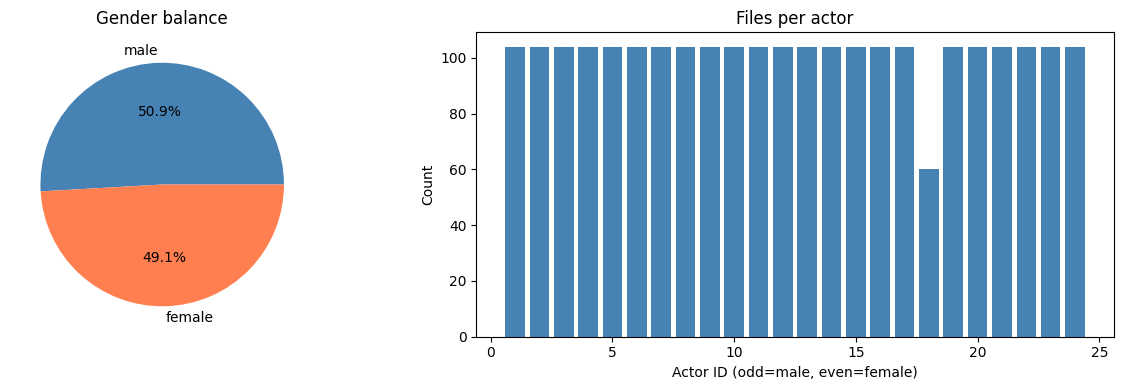

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# gender balance
gender_counts = df['gender'].value_counts()
axes[0].pie(gender_counts.values, labels=gender_counts.index,
            autopct='%1.1f%%', colors=['steelblue', 'coral'])
axes[0].set_title('Gender balance')

# files per actor
actor_counts = df['actor'].value_counts().sort_index()
axes[1].bar(actor_counts.index, actor_counts.values, color='steelblue')
axes[1].set_title('Files per actor')
axes[1].set_xlabel('Actor ID (odd=male, even=female)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [12]:
summary = df.groupby('label').agg(
    count       = ('filepath', 'count'),
    speech      = ('channel', lambda x: (x == 1).sum()),
    song        = ('channel', lambda x: (x == 2).sum()),
    male        = ('gender', lambda x: (x == 'male').sum()),
    female      = ('gender', lambda x: (x == 'female').sum()),
    normal_int  = ('intensity', lambda x: (x == 1).sum()),
    strong_int  = ('intensity', lambda x: (x == 2).sum()),
).reset_index()

print(summary.to_string(index=False))

    label  count  speech  song  male  female  normal_int  strong_int
    angry    376     192   184   192     184         188         188
     calm    376     192   184   192     184         188         188
  disgust    192     192     0    96      96          96          96
  fearful    376     192   184   192     184         188         188
    happy    376     192   184   192     184         188         188
  neutral    188      96    92    96      92         188           0
      sad    376     192   184   192     184         188         188
surprised    192     192     0    96      96          96          96


In [13]:
os.makedirs('../outputs', exist_ok=True)
df.drop(columns=['channel_name']).to_csv('../outputs/metadata.csv', index=False)
print(f"Saved metadata.csv with {len(df)} rows")


Saved metadata.csv with 2452 rows
Week 4 complete — next: feature extraction in notebook 02
